# Análisis de datos - TP Final

In [148]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import kagglehub
from scipy import stats as st
from scipy.stats import describe

In [149]:
pd.options.display.float_format = '{:,.4f}'.format

## Exploración y comprensión de los datos (Joni)

### Cargar el dataset proporcionado y realizar un análisis exploratorio de los datos.

In [150]:
# Download latest version
path = kagglehub.dataset_download("asaniczka/tmdb-movies-dataset-2023-930k-movies")

print("Path to dataset files:", path)

Path to dataset files: /home/jbmild/.cache/kagglehub/datasets/asaniczka/tmdb-movies-dataset-2023-930k-movies/versions/904


In [151]:
df = pd.read_csv(path + "/TMDB_movie_dataset_v11.csv", na_values='sin especificar', encoding='ISO-8859-1')
df.head()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.3640,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Inception,"Cobb, a skilled thief who commits corporate es...",83.9520,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.4170,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Interstellar,The adventures of a group of explorers who mak...,140.2410,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.5120,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.6430,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.5730,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.9320,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.7100,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,The Avengers,When an unexpected enemy emerges and threatens...,98.0820,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."


In [152]:
df.shape

(1402215, 24)

In [153]:
df.columns

Index(['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date',
       'revenue', 'runtime', 'adult', 'backdrop_path', 'budget', 'homepage',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'tagline', 'genres',
       'production_companies', 'production_countries', 'spoken_languages',
       'keywords'],
      dtype='object')

In [154]:
df.head(5)

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.3640,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Inception,"Cobb, a skilled thief who commits corporate es...",83.9520,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.4170,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Interstellar,The adventures of a group of explorers who mak...,140.2410,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.5120,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.6430,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.5730,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.9320,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.7100,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,The Avengers,When an unexpected enemy emerges and threatens...,98.0820,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."


### Describir las características principales del dataset, incluyendo el número de observaciones, número de variables y tipos de datos.


In [155]:
# Tipo por columna.
df.dtypes.to_frame("dtype")

,dtype
id,int64
title,object
vote_average,float64
vote_count,int64
status,object
release_date,object
revenue,int64
runtime,int64
adult,bool
backdrop_path,object


In [156]:
df['vote_average'].describe()

count   1,402,215.0000
mean            1.5713
std             2.8670
min             0.0000
25%             0.0000
50%             0.0000
75%             1.5000
max            10.0000
Name: vote_average, dtype: float64

In [157]:
df['vote_count'].describe()

count   1,402,215.0000
mean           15.3024
std           286.8610
min             0.0000
25%             0.0000
50%             0.0000
75%             1.0000
max        34,495.0000
Name: vote_count, dtype: float64

In [158]:
df['status'].unique()

array(['Released', 'Planned', 'In Production', 'Post Production',
       'Rumored', 'Canceled'], dtype=object)

In [159]:
pd.to_datetime(df['release_date'], errors='coerce').max()

Timestamp('2099-12-31 00:00:00')

In [160]:
pd.to_datetime(df['release_date'], errors='coerce').min()

Timestamp('1800-01-01 00:00:00')

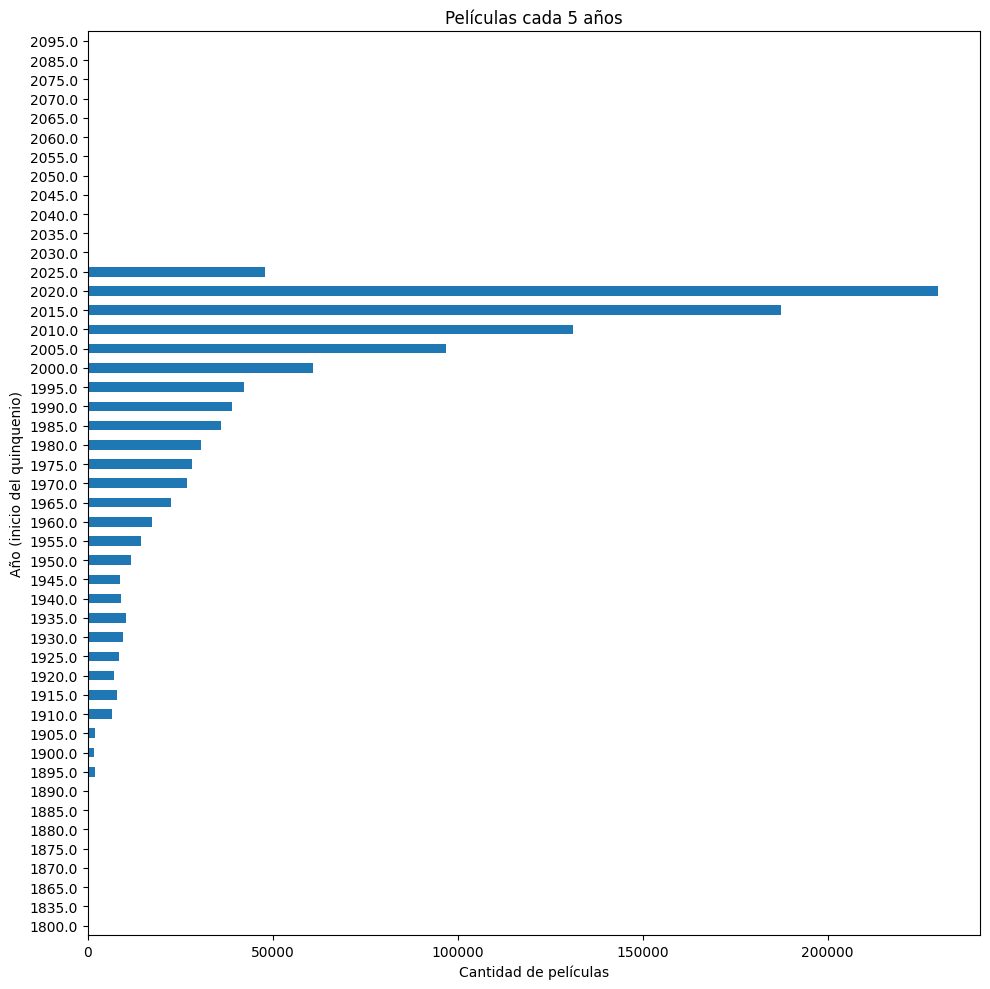

In [161]:
df['year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year.dropna().astype(int)
df['quinquenio'] = (df['year'] // 5) * 5   # 1992→1990, 1997→1995, 2003→2000
peliculas_por_5_anos = df['quinquenio'].value_counts().sort_index()
peliculas_por_5_anos.plot(kind='barh', figsize=(10, 10))
plt.xlabel('Cantidad de películas')
plt.ylabel('Año (inicio del quinquenio)')
plt.title('Películas cada 5 años')
plt.tight_layout()
plt.show()

In [162]:
df['revenue'].describe()

count       1,402,215.0000
mean          621,673.2683
std        19,173,679.0218
min               -12.0000
25%                 0.0000
50%                 0.0000
75%                 0.0000
max     4,999,999,999.0000
Name: revenue, dtype: float64

In [163]:
df['runtime'].describe()

count   1,402,215.0000
mean           44.1746
std            60.7054
min           -28.0000
25%             0.0000
50%            16.0000
75%            85.0000
max        14,400.0000
Name: runtime, dtype: float64

In [164]:
df['adult'].unique()

array([False,  True])

In [165]:
df['budget'].describe()

count     1,402,215.0000
mean        237,372.0977
std       5,078,396.6900
min               0.0000
25%               0.0000
50%               0.0000
75%               0.0000
max     999,999,999.0000
Name: budget, dtype: float64

In [166]:
df['original_language'].unique()

array(['en', 'ko', 'fr', 'ja', 'it', 'es', 'pl', 'pt', 'hi', 'tr', 'da',
       'de', 'cn', 'id', 'zh', 'sv', 'el', 'ru', 'sr', 'fa', 'th', 'ar',
       'no', 'nb', 'fi', 'te', 'la', 'nl', 'hu', 'he', 'is', 'ro', 'gl',
       'uk', 'eu', 'et', 'bs', 'bn', 'xx', 'sh', 'km', 'cs', 'tn', 'ml',
       'mk', 'ga', 'hy', 'ku', 'ka', 'ta', 'kn', 'tl', 'vi', 'ca', 'dz',
       'sw', 'wo', 'kk', 'sk', 'mi', 'lv', 'bo', 'mn', 'ps', 'lt', 'ur',
       'sl', 'sc', 'af', 'hr', 'se', 'iu', 'ms', 'bm', 'mr', 'bg', 'cy',
       'lo', 'am', 'xh', 'qu', 'yi', 'yo', 'sq', 'pa', 'eo', 'gu', 'zu',
       'st', 'ne', 'ak', 'mt', 'rw', 'as', 'ay', 'ln', 'mo', 'si', 'so',
       'ff', 'ky', 'kl', 'ab', 'az', 'ik', 'jv', 'sn', 'li', 'fo', 'tg',
       'my', 'ks', 'su', 'lb', 'ht', 'tk', 'sm', 'rm', 'sa', 'ha', 'fy',
       'or', 'ny', 'bi', 'gd', 'be', 'om', 'uz', 'cr', 'mg', 'gn', 'mh',
       'ia', 'co', 'tw', 'nn', 'ig', 'tt', 'ug', 'nv', 'os', 'dv', 'ie',
       'ba', 'oc', 'sd', 'sg', 'nd', 'ty', 'kw', 't

In [167]:
df['popularity'].describe()

count   1,402,215.0000
mean            1.0235
std             6.8462
min             0.0000
25%             0.0714
50%             0.6000
75%             0.7140
max         2,994.3570
Name: popularity, dtype: float64

In [168]:
df['tagline'].head()

0                 Your mind is the scene of the crime.
1    Mankind was born on Earth. It was never meant ...
2                    Welcome to a world without rules.
3                          Enter the world of Pandora.
4                              Some assembly required.
Name: tagline, dtype: object

In [169]:
sorted(
    df['genres']
      .dropna()           # saca NaN
      .astype(str)        # asegura que todo sea string
      .str.split(',')
      .explode()
      .str.strip()
      .unique()
)

['Action',
 'Adventure',
 'Animation',
 'Comedy',
 'Crime',
 'Documentary',
 'Drama',
 'Family',
 'Fantasy',
 'History',
 'Horror',
 'Music',
 'Mystery',
 'Romance',
 'Science Fiction',
 'TV Movie',
 'Thriller',
 'War',
 'Western']

In [170]:
production_companies = sorted(
    df['production_companies']
      .dropna()           # saca NaN
      .astype(str)        # asegura que todo sea string
      .str.split(',')
      .explode()
      .str.strip()
      .unique()
)

production_companies

['',
 '"A ME AND YOU MOTION PICTURE"',
 '"Creo" of M. Bystritsky',
 '"DIA" Productions GmbH & Co. KG',
 '"Dann Moss Entertainment',
 '"En TeorÃ\xada" Producciones',
 '"Film Company "Karbush"',
 '"Filma" Shareholders\' Association',
 '"G" P.C. S.A.',
 '"GREEN" Productions',
 '"Hanochi" Film Partners',
 '"Haruka\'s Pottery" Film Partners',
 '"Hypnosis Mic - Division Rap Battle" Rule the Stage Production Committee',
 '"I Used To Fuck People Like You In Prison" Records',
 '"It Goes to 11" Productions',
 '"Just The Filter" Productions',
 '"M" Films',
 '"MIYAGINO" Film Partners',
 '"Mega" Marbella Entertainment Groups & Artists',
 '"N" Film Studio',
 '"Shine kino" studio',
 '"Srcem za djecu" Sarajevo',
 '"Step" Ltd KinoÅ\x9firkÉ\x99ti',
 '"Swaying Mariko" Film Production Committee',
 '"TOKYO Ainu" Film Production Committee',
 '"The Mountain" Production Committee',
 '"Virtuoz" TRK',
 '"Weathering With You" Film Partners',
 '"Yeni Film" Film Company',
 '"unknown" estudios',
 '"á\x83¥á\x83\x90á

In [171]:
len(production_companies)

187835

In [172]:
production_countries = sorted(
    df['production_countries']
      .dropna()           # saca NaN
      .astype(str)        # asegura que todo sea string
      .str.split(',')
      .explode()
      .str.strip()
      .unique()
)

production_countries

['Afghanistan',
 'Albania',
 'Algeria',
 'American Samoa',
 'Andorra',
 'Angola',
 'Anguilla',
 'Antarctica',
 'Antigua and Barbuda',
 'Argentina',
 'Armenia',
 'Aruba',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Bolivia',
 'Bosnia and Herzegovina',
 'Botswana',
 'Bouvet Island',
 'Brazil',
 'British Indian Ocean Territory',
 'British Virgin Islands',
 'Brunei Darussalam',
 'Bulgaria',
 'Burkina Faso',
 'Burma',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Cape Verde',
 'Cayman Islands',
 'Central African Republic',
 'Chad',
 'Chile',
 'China',
 'Christmas Island',
 'Cocos  Islands',
 'Colombia',
 'Comoros',
 'Congo',
 'Cook Islands',
 'Costa Rica',
 "Cote D'Ivoire",
 'Croatia',
 'Cuba',
 'Cyprus',
 'Czech Republic',
 'Czechoslovakia',
 'Denmark',
 'Djibouti',
 'Dominica',
 'Dominican Republic',
 'East Germany',
 'East Timor',
 'Ecuador',
 'Egypt',
 'El Salvador

In [173]:
len(production_countries)

250

In [174]:
spoken_languages = sorted(
    df['spoken_languages']
      .dropna()           # saca NaN
      .astype(str)        # asegura que todo sea string
      .str.split(',')
      .explode()
      .str.strip()
      .unique()
)

spoken_languages

['Abkhazian',
 'Afar',
 'Afrikaans',
 'Akan',
 'Albanian',
 'Amharic',
 'Arabic',
 'Aragonese',
 'Armenian',
 'Assamese',
 'Avaric',
 'Avestan',
 'Aymara',
 'Azerbaijani',
 'Bambara',
 'Bashkir',
 'Basque',
 'Belarusian',
 'Bengali',
 'Bislama',
 'Bosnian',
 'Breton',
 'Bulgarian',
 'Burmese',
 'Cantonese',
 'Catalan',
 'Chamorro',
 'Chechen',
 'Chichewa; Nyanja',
 'Chuvash',
 'Cornish',
 'Corsican',
 'Cree',
 'Croatian',
 'Czech',
 'Danish',
 'Divehi',
 'Dutch',
 'Dzongkha',
 'English',
 'Esperanto',
 'Estonian',
 'Ewe',
 'Faroese',
 'Fijian',
 'Finnish',
 'French',
 'Frisian',
 'Fulah',
 'Gaelic',
 'Galician',
 'Ganda',
 'Georgian',
 'German',
 'Greek',
 'Guarani',
 'Gujarati',
 'Haitian; Haitian Creole',
 'Hausa',
 'Hebrew',
 'Herero',
 'Hindi',
 'Hiri Motu',
 'Hungarian',
 'Icelandic',
 'Ido',
 'Igbo',
 'Indonesian',
 'Interlingua',
 'Interlingue',
 'Inuktitut',
 'Inupiaq',
 'Irish',
 'Italian',
 'Japanese',
 'Javanese',
 'Kalaallisut',
 'Kannada',
 'Kanuri',
 'Kashmiri',
 'Kazakh'

In [175]:
len(spoken_languages)

186

In [176]:
keywords = sorted(
    df['keywords']
      .dropna()           # saca NaN
      .astype(str)        # asegura que todo sea string
      .str.split(',')
      .explode()
      .str.strip()
      .unique()
)

keywords

['',
 '"me escanee el ojo',
 '"on the "brink of death"',
 '"on the brink of death"',
 '"robin hood" thieves',
 '"spider" john koerner',
 '"the dunce" series',
 '"where every choice changes your life."',
 '"à¶\x85à¶´à·\x92 à¶¶à¶½à·\x8aà¶½à·\x9d à·\x80à¶\x9cà·\x9a à¶\x9aà·\x8fà¶\x9cà¶±à·\x8aà¶±à·\x80à·\x8f à·\x83à¶»à·\x8a à¶´à·\x9cà¶©à·\x92 à¶¸à·\x83à·\x8aà¶\x9aà¶§à·\x8aà¶§à¶\x9aà¶§"',
 '#',
 '#bobimovie',
 '#brazilianblackmusic',
 '#comedy #gangsters #fantasy #lawofattraction #funny #release #uk #usa #love #evil #guns #humor #anotherexcellentday #guyritchie #snatch #quentintarantino #trainspotting',
 '#deliveranceshortfilm',
 '#finalclash',
 '#lauterwerden',
 '#likeme',
 '#loveoverwealth',
 '#milamovie',
 '#mute',
 '#nghesieude',
 '#nsd',
 '#parisfashion #sexygirlstyle #parisstreetstyle #frenchfashionvibes #gothfashion #y2kstyle #darkaesthetic #streetwearvibes #edgystyle #artsylook',
 '#raffyhdz',
 '#tahilsumkan',
 '#terremoto',
 '#tipmuskan',
 '#tubeclash',
 '#walktalk',
 '#yeahhh',
 "

In [177]:
len(keywords)

69008

In [178]:
# Contar la cantidad de valores nulos en cada columna
df.isna().sum()  

id                            0
title                        18
vote_average                  0
vote_count                    0
status                        0
release_date             306567
revenue                       0
runtime                       0
adult                         0
backdrop_path           1052416
budget                        0
homepage                1257714
imdb_id                  737444
original_language             0
original_title               18
overview                 320421
popularity                    0
poster_path              494793
tagline                 1206945
genres                   612932
production_companies     802951
production_countries     675198
spoken_languages         648261
keywords                1053797
year                     306567
quinquenio               306567
dtype: int64

In [179]:
# Calcular la proporción de valores nulos en cada columna
df.isna().mean().round(4)*100

id                      0.0000
title                   0.0000
vote_average            0.0000
vote_count              0.0000
status                  0.0000
release_date           21.8600
revenue                 0.0000
runtime                 0.0000
adult                   0.0000
backdrop_path          75.0500
budget                  0.0000
homepage               89.6900
imdb_id                52.5900
original_language       0.0000
original_title          0.0000
overview               22.8500
popularity              0.0000
poster_path            35.2900
tagline                86.0700
genres                 43.7100
production_companies   57.2600
production_countries   48.1500
spoken_languages       46.2300
keywords               75.1500
year                   21.8600
quinquenio             21.8600
dtype: float64

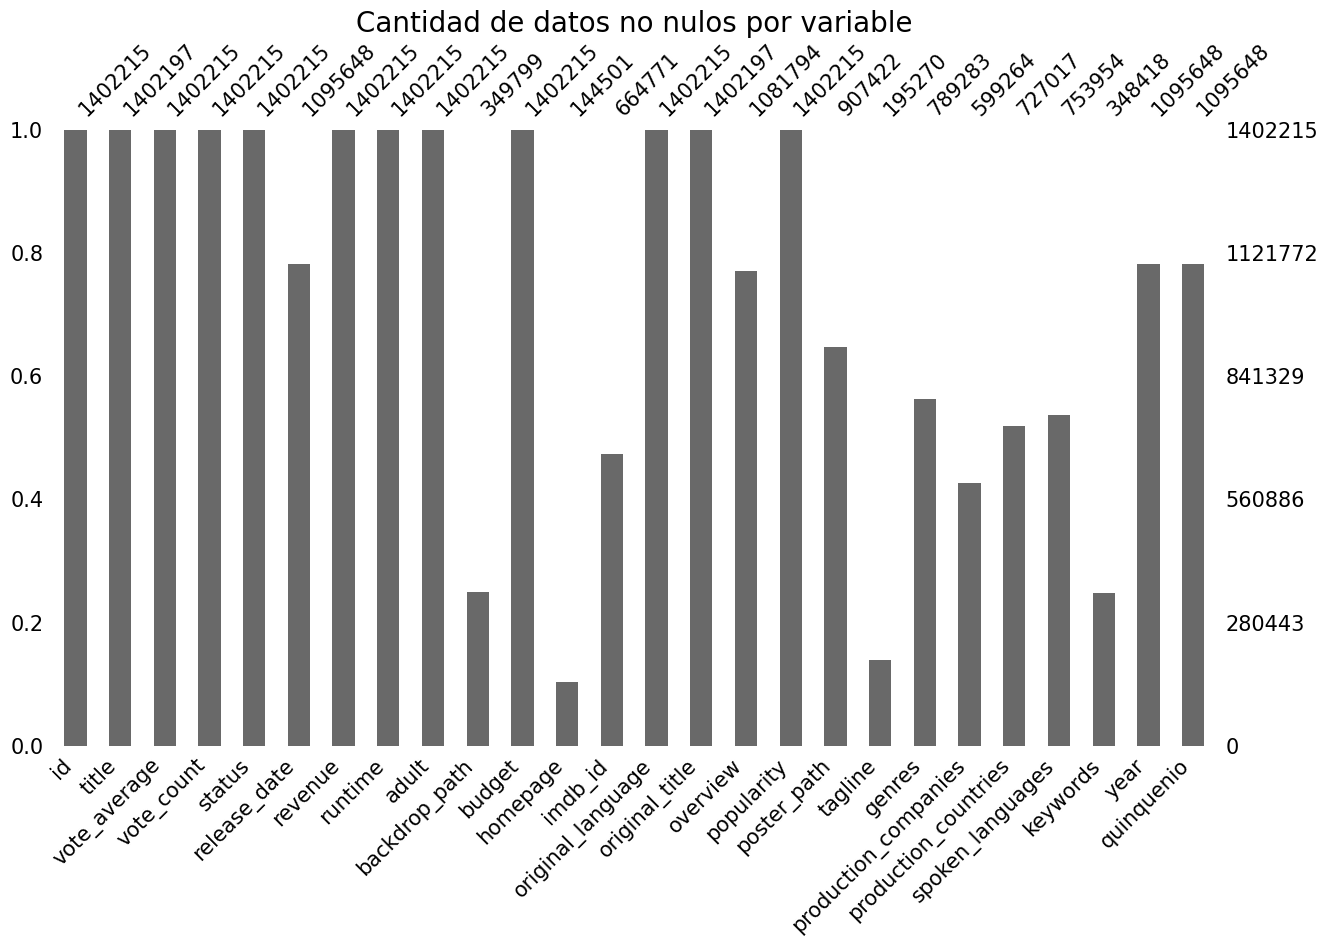

In [180]:
msno.bar(df, fontsize=15, figsize=(15,8))
plt.title("Cantidad de datos no nulos por variable", fontsize=20)
plt.show()

<Axes: >

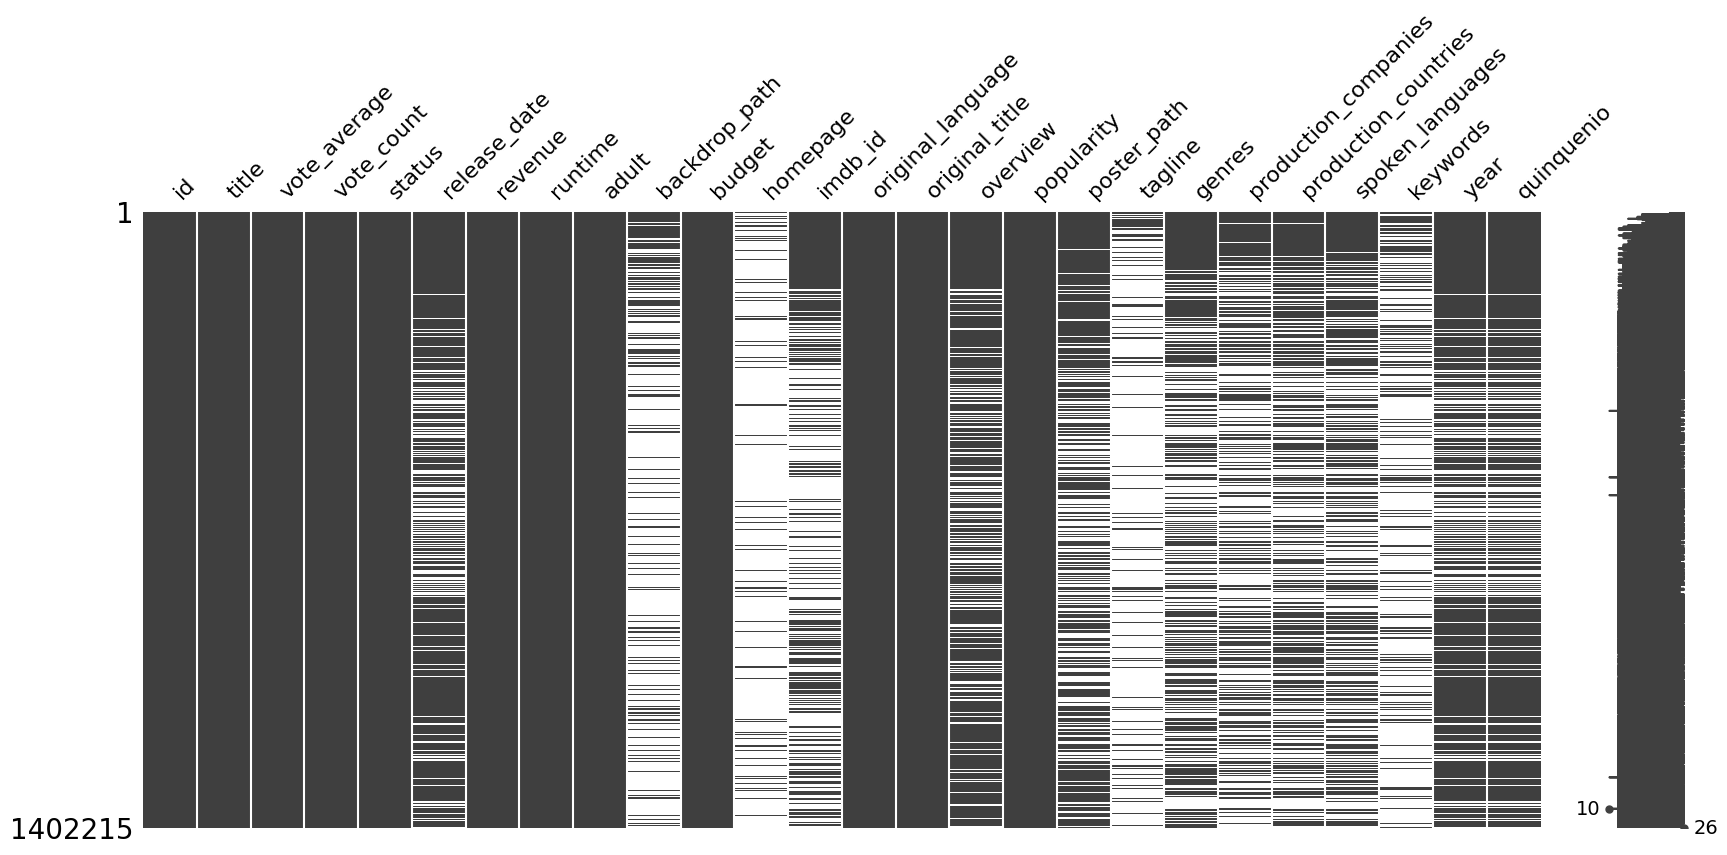

In [181]:
# Matriz de valores faltantes
msno.matrix(df, figsize=(20,8))

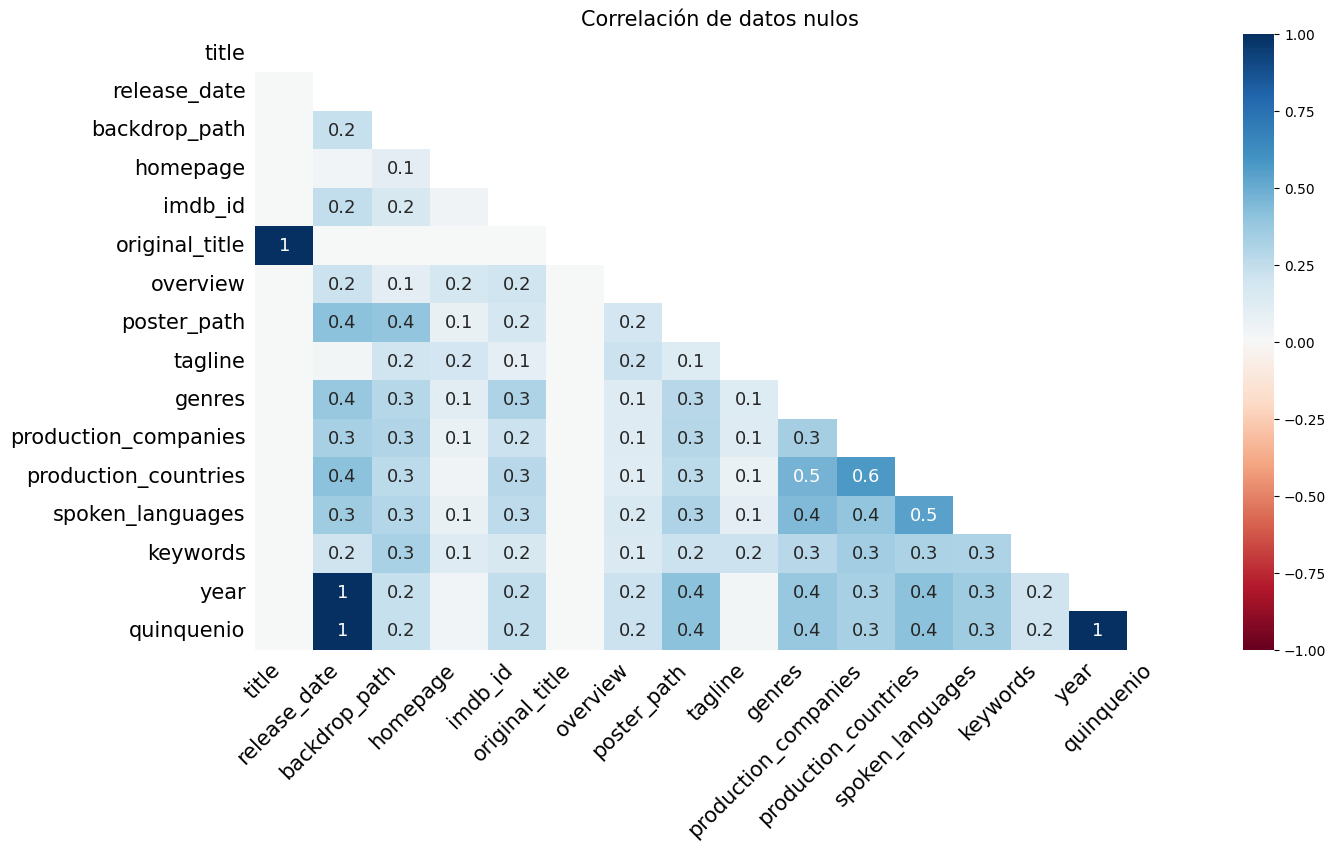

In [182]:
msno.heatmap(df, fontsize=15, figsize=(15,8))
plt.title("Correlación de datos nulos", fontsize=15)
plt.show()

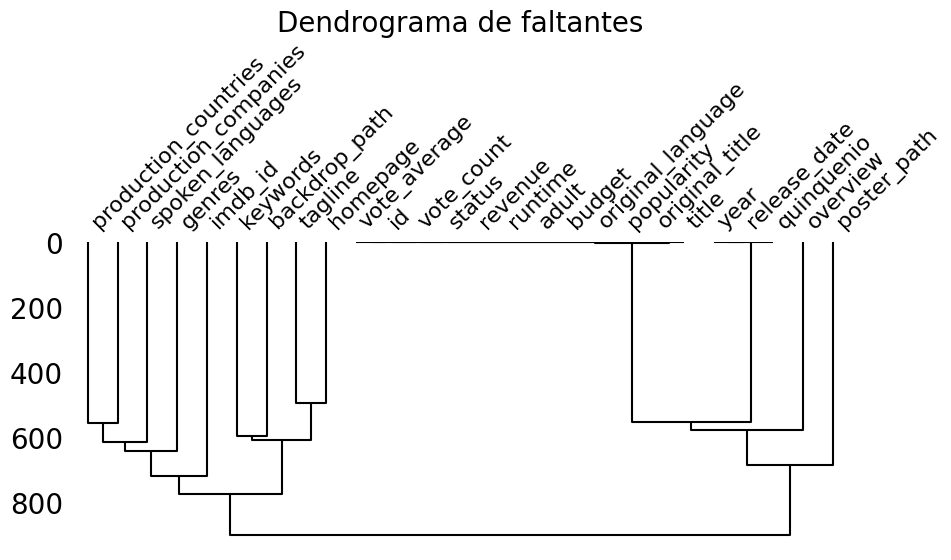

In [183]:
msno.dendrogram(df, figsize=(10,4))
plt.title('Dendrograma de faltantes', fontsize=20)
plt.show()

### Identificar patrones generales y distribuciones.


In [184]:
# Distribución de variables numéricas: estadísticos y rangos.
df.describe().T


,count,mean,std,min,25%,50%,75%,max
id,"1,402,215.0000","889,837.1235","472,755.9237",2.0000,"489,772.5000","912,299.0000","1,304,189.5000","1,668,654.0000"
vote_average,"1,402,215.0000",1.5713,2.8670,0.0000,0.0000,0.0000,1.5000,10.0000
vote_count,"1,402,215.0000",15.3024,286.8610,0.0000,0.0000,0.0000,1.0000,"34,495.0000"
revenue,"1,402,215.0000","621,673.2683","19,173,679.0218",-12.0000,0.0000,0.0000,0.0000,"4,999,999,999.0000"
runtime,"1,402,215.0000",44.1746,60.7054,-28.0000,0.0000,16.0000,85.0000,"14,400.0000"
budget,"1,402,215.0000","237,372.0977","5,078,396.6900",0.0000,0.0000,0.0000,0.0000,"999,999,999.0000"
popularity,"1,402,215.0000",1.0235,6.8462,0.0000,0.0714,0.6000,0.7140,"2,994.3570"
year,"1,095,648.0000","2,001.1074",26.4812,"1,800.0000","1,991.0000","2,012.0000","2,020.0000","2,099.0000"
quinquenio,"1,095,648.0000","1,999.1029",26.5155,"1,800.0000","1,990.0000","2,010.0000","2,020.0000","2,095.0000"


**Variables numéricas continuas** — Un gráfico por celda. Donde hay muchos ceros, se excluyen y/o se usa `log1p` (ingresos, presupuesto, conteos, etc.).


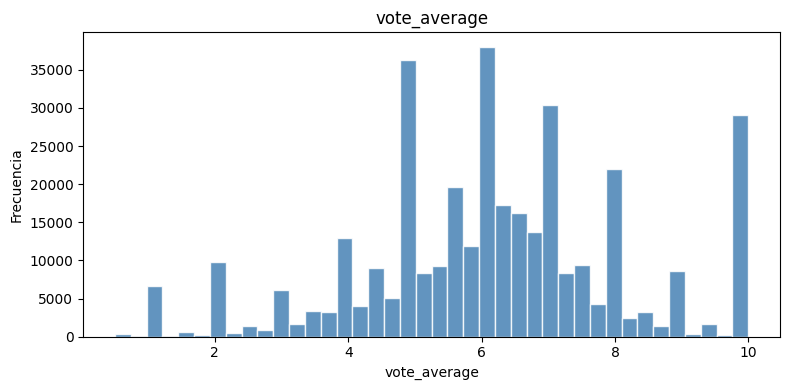

In [185]:
# vote_average (solo 0 < x ≤ 10; excluye promedios en 0)
col = "vote_average"
s = pd.to_numeric(df[col], errors="coerce").dropna()
n0 = int((s == 0).sum())
s_plot = s[(s > 0) & (s <= 10)]
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(s_plot, bins=40, color="steelblue", edgecolor="white", alpha=0.85)
ax.set_xlabel("vote_average")
ax.set_ylabel("Frecuencia")
ax.set_title(f"vote_average")
ax.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()


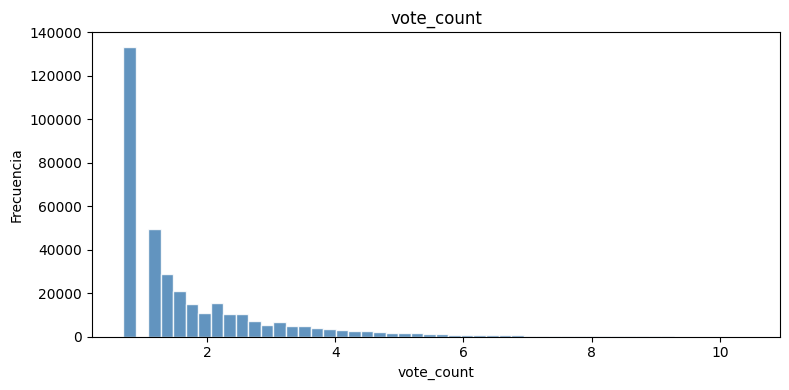

In [186]:
# vote_count (log1p; excluye ceros)
col = "vote_count"
s = pd.to_numeric(df[col], errors="coerce").dropna()
n0 = int((s == 0).sum())
s_plot = s[s > 0]
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(np.log1p(s_plot), bins=50, color="steelblue", edgecolor="white", alpha=0.85)
ax.set_xlabel(col)
ax.set_ylabel("Frecuencia")
ax.set_title("vote_count")
ax.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()


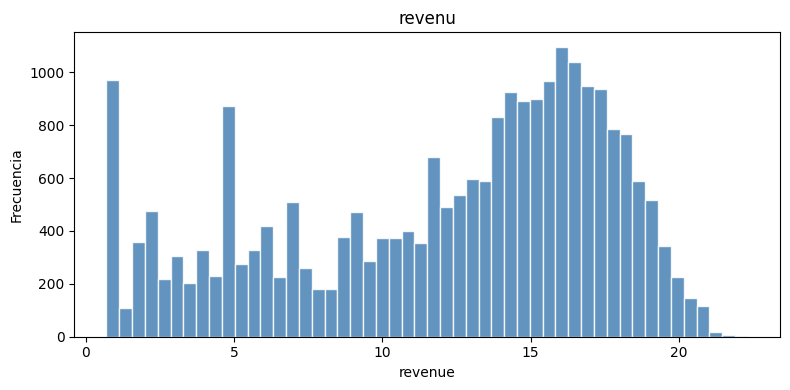

In [187]:
# revenue (log1p; excluye ceros)
col = "revenue"
s = pd.to_numeric(df[col], errors="coerce").dropna()
n0 = int((s == 0).sum())
s_plot = s[s > 0]
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(np.log1p(s_plot), bins=50, color="steelblue", edgecolor="white", alpha=0.85)
ax.set_xlabel(f"{col}")
ax.set_ylabel("Frecuencia")
ax.set_title(f"revenu")
ax.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()


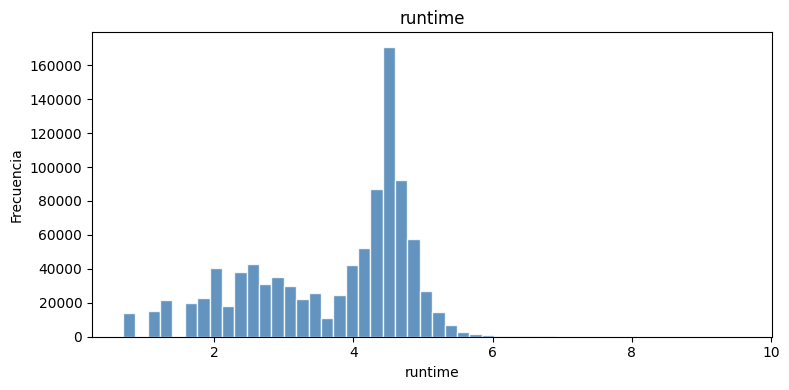

In [188]:
# runtime (log1p; excluye ceros)
col = "runtime"
s = pd.to_numeric(df[col], errors="coerce").dropna()
n0 = int((s == 0).sum())
s_plot = s[s > 0]
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(np.log1p(s_plot), bins=50, color="steelblue", edgecolor="white", alpha=0.85)
ax.set_xlabel(col)
ax.set_ylabel("Frecuencia")
ax.set_title("runtime")
ax.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()


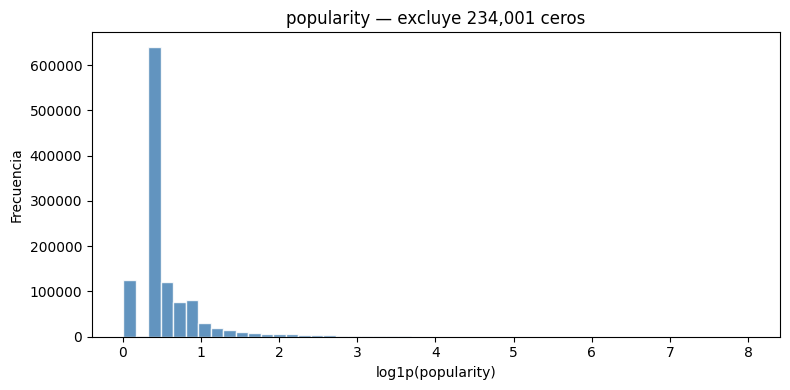

In [189]:
# popularity (log1p; excluye ceros)
col = "popularity"
s = pd.to_numeric(df[col], errors="coerce").dropna()
n0 = int((s == 0).sum())
s_plot = s[s > 0]
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(np.log1p(s_plot), bins=50, color="steelblue", edgecolor="white", alpha=0.85)
ax.set_xlabel(f"log1p({col})")
ax.set_ylabel("Frecuencia")
ax.set_title(f"popularity — excluye {n0:,} ceros")
ax.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()


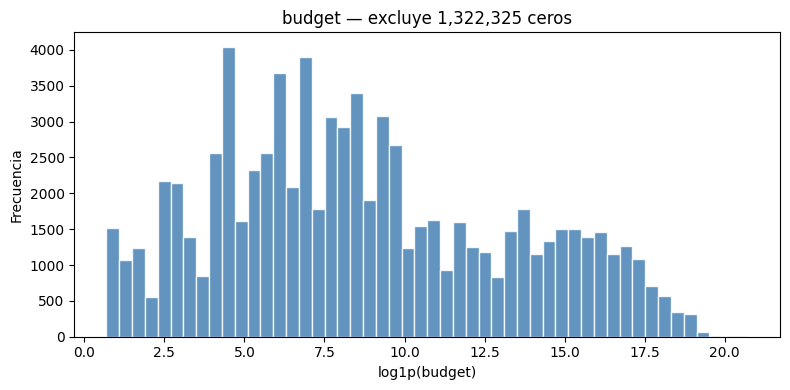

In [190]:
# budget (log1p; excluye ceros — mismo patrón que revenue)
col = "budget"
s = pd.to_numeric(df[col], errors="coerce").dropna()
n0 = int((s == 0).sum())
s_plot = s[s > 0]
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(np.log1p(s_plot), bins=50, color="steelblue", edgecolor="white", alpha=0.85)
ax.set_xlabel(f"log1p({col})")
ax.set_ylabel("Frecuencia")
ax.set_title(f"budget — excluye {n0:,} ceros")
ax.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()


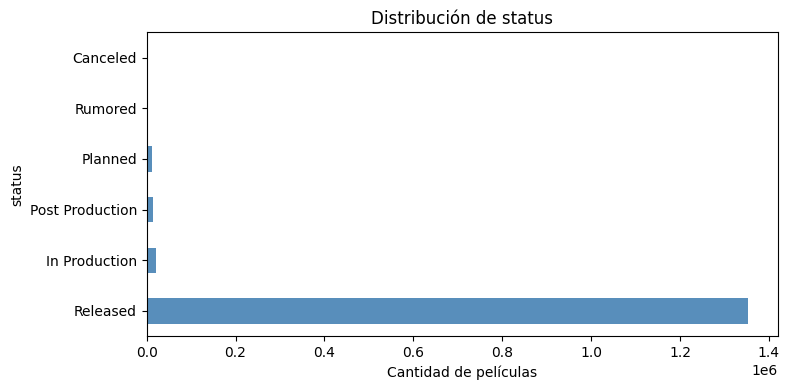

In [192]:
# status (categórica)
vc = df["status"].value_counts(dropna=False)
fig, ax = plt.subplots(figsize=(8, 4))
vc.plot(kind="barh", ax=ax, color="steelblue", alpha=0.9)
ax.set_xlabel("Cantidad de películas")
ax.set_title("Distribución de status")
plt.tight_layout()
plt.show()


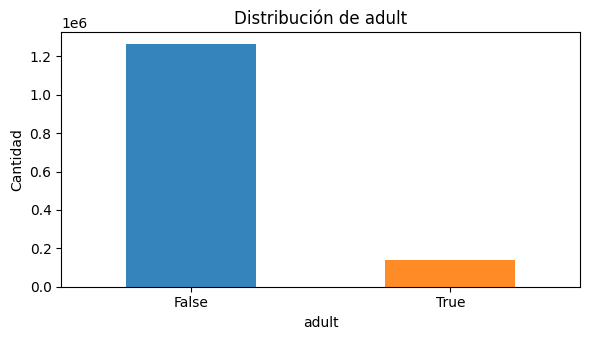

In [193]:
# adult (categórica binaria)
vc = df["adult"].value_counts(dropna=False)
fig, ax = plt.subplots(figsize=(6, 3.5))
vc.plot(kind="bar", ax=ax, color=["tab:blue", "tab:orange"], alpha=0.9, rot=0)
ax.set_ylabel("Cantidad")
ax.set_title("Distribución de adult")
plt.tight_layout()
plt.show()


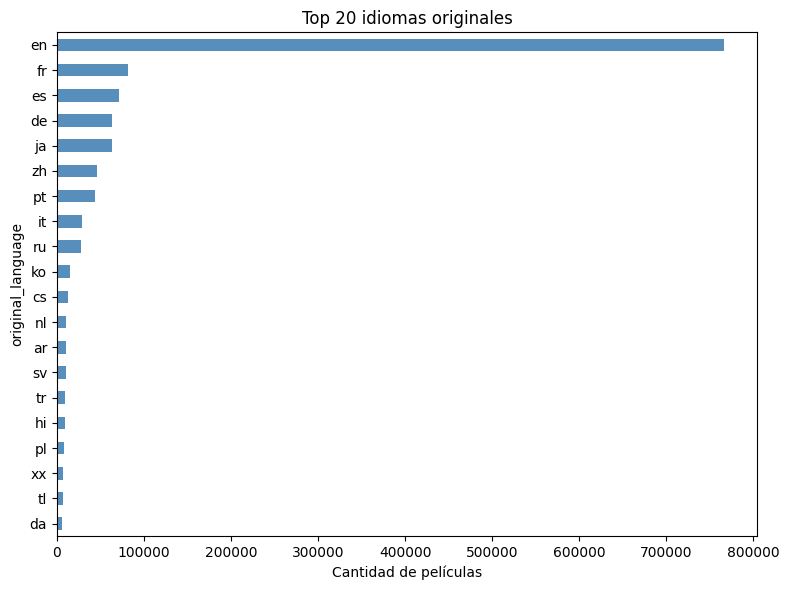

In [194]:
# original_language (top 20 idiomas)
vc = df["original_language"].fillna("(sin dato)").value_counts().head(20)
fig, ax = plt.subplots(figsize=(8, 6))
vc.sort_values().plot(kind="barh", ax=ax, color="steelblue", alpha=0.9)
ax.set_xlabel("Cantidad de películas")
ax.set_title("Top 20 idiomas originales")
plt.tight_layout()
plt.show()


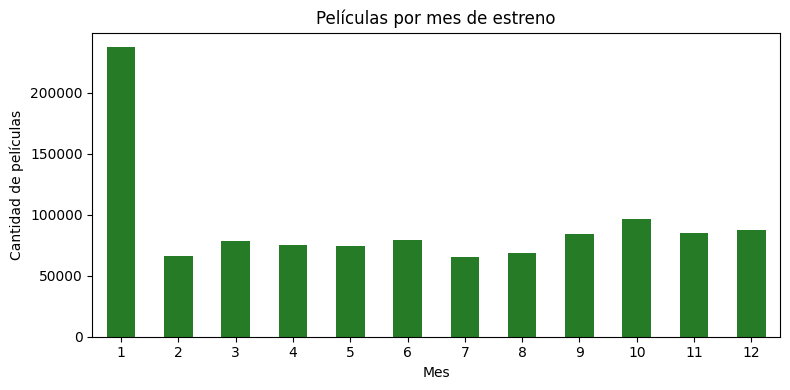

In [195]:
# Mes de estreno (1–12; desde release_date)
m = pd.to_datetime(df["release_date"], errors="coerce").dt.month.dropna().astype(int)
fig, ax = plt.subplots(figsize=(8, 4))
m.value_counts().sort_index().plot(kind="bar", ax=ax, color="darkgreen", alpha=0.85, rot=0)
ax.set_xlabel("Mes")
ax.set_ylabel("Cantidad de películas")
ax.set_title("Películas por mes de estreno")
plt.tight_layout()
plt.show()


### Fecha de estreno (distribución temporal)


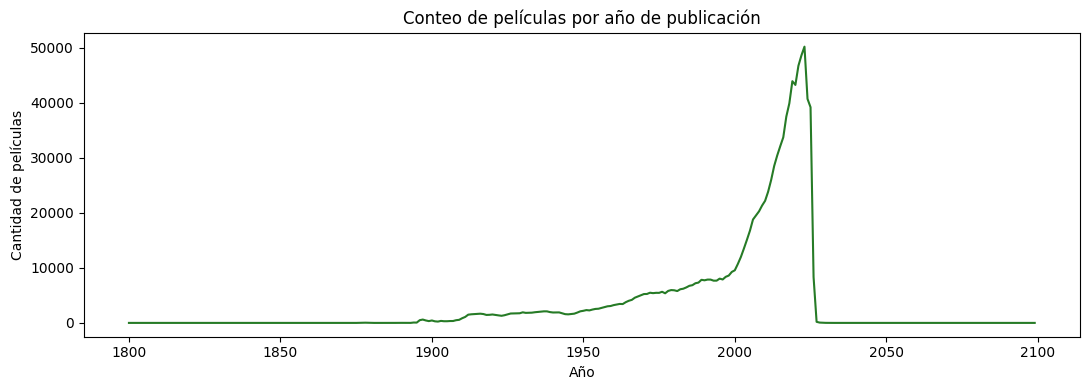

In [191]:
# Películas por año de estreno (patrón temporal).
years = pd.to_datetime(df["release_date"], errors="coerce").dt.year.dropna().astype(int)
ax = years.value_counts().sort_index().plot(figsize=(11, 4), color="darkgreen", alpha=0.85)
plt.xlabel("Año")
plt.ylabel("Cantidad de películas")
plt.title("Conteo de películas por año de publicación")
plt.tight_layout()
plt.show()


### Identificar errores, outliers (anomalías), valores faltantes y su tipo (MCAR, MAR, MNAR).

In [197]:
# Valores faltantes por columna (conteo y % sobre el total de filas).
miss = df.isna().sum().sort_values(ascending=False)
miss_pct = (miss / len(df) * 100).round(2)
pd.DataFrame({"nulos": miss, "pct": miss_pct})[miss > 0]


,nulos,pct
homepage,1257714,89.6900
tagline,1206945,86.0700
keywords,1053797,75.1500
backdrop_path,1052416,75.0500
production_companies,802951,57.2600
imdb_id,737444,52.5900
production_countries,675198,48.1500
spoken_languages,648261,46.2300
genres,612932,43.7100
poster_path,494793,35.2900


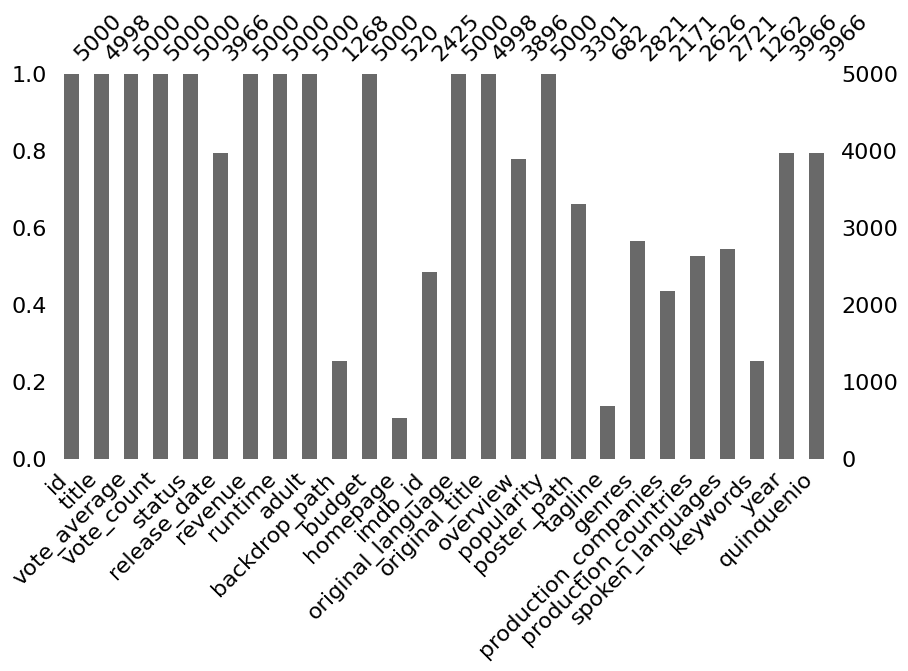

In [198]:
# Visualización de patrones de ausencia (missingno).
# Con muchas filas, una muestra conserva la forma del patrón de nulos.
_sample = df.sample(n=min(5000, len(df)), random_state=42)
msno.bar(_sample, figsize=(10, 5))
plt.show()


<Axes: >

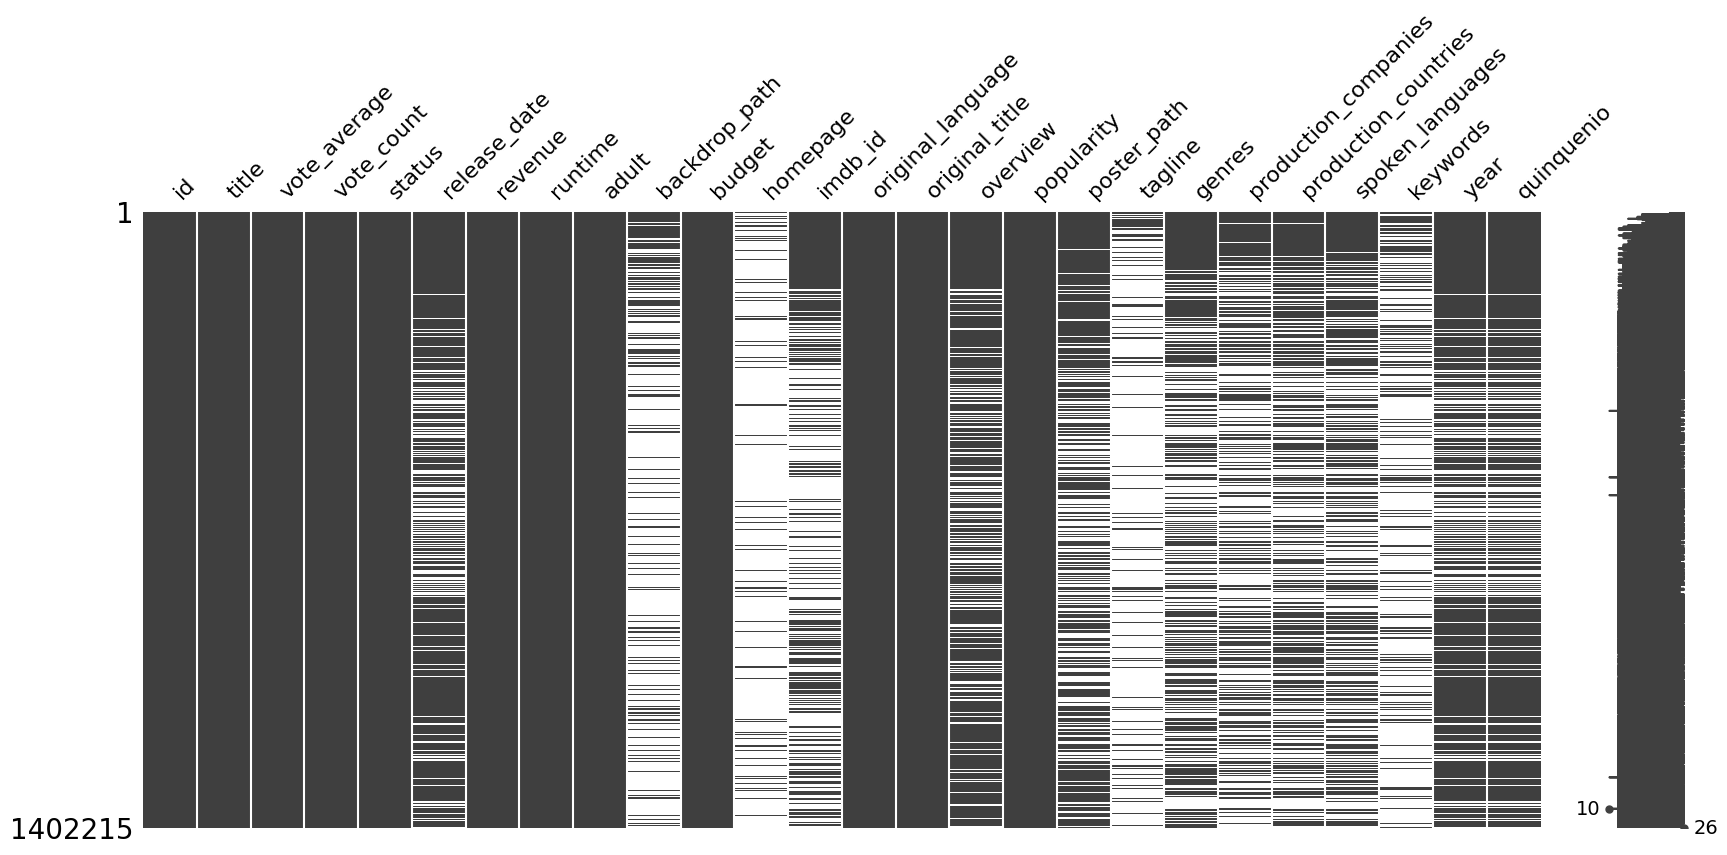

In [201]:
# Matriz de valores faltantes
msno.matrix(df, figsize=(20,8))

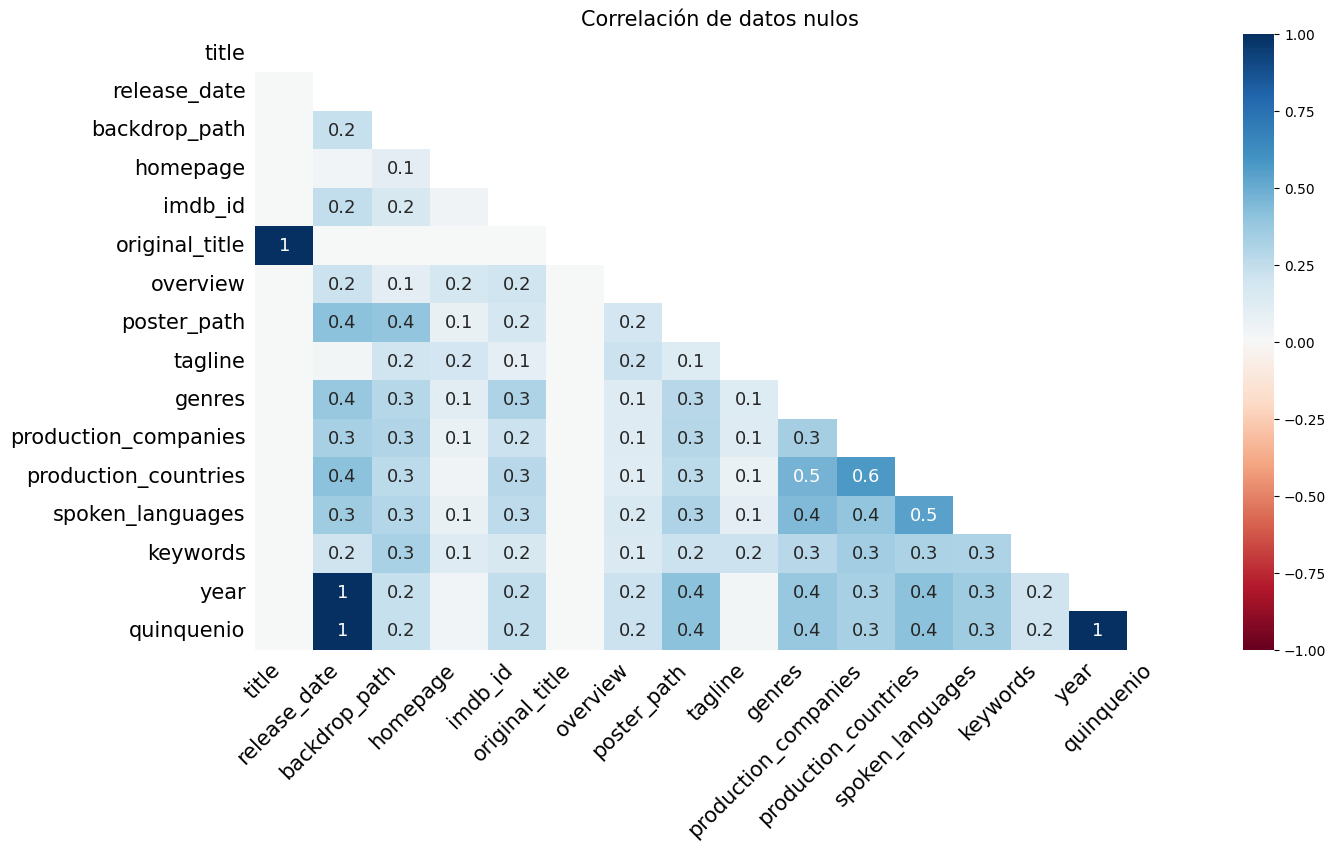

In [202]:
msno.heatmap(df, fontsize=15, figsize=(15,8))
plt.title("Correlación de datos nulos", fontsize=15)
plt.show()

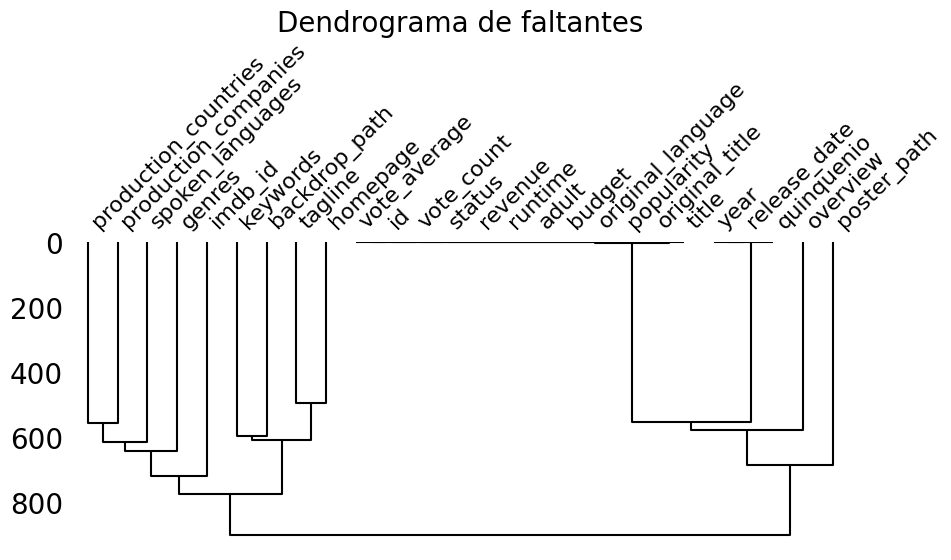

In [203]:
msno.dendrogram(df, figsize=(10,4))
plt.title('Dendrograma de faltantes', fontsize=20)
plt.show()

In [200]:
# Outliers: regla IQR (1.5×IQR) en todas las columnas numéricas.
# Se excluye `id` (identificador; los "outliers" no son interpretables como anomalías de negocio).
def iqr_outlier_pct(series):
    s = pd.to_numeric(series, errors="coerce").dropna()
    if len(s) < 4:
        return len(s), np.nan, np.nan
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    if iqr == 0:
        return len(s), 0, 0.0
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    out = (s < low) | (s > high)
    return len(s), int(out.sum()), 100 * out.mean()

num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != "id"]
rows = []
for col in sorted(num_cols):
    n, n_out, pct = iqr_outlier_pct(df[col])
    rows.append({"columna": col, "n_validos": n, "n_outliers_IQR": n_out, "pct_outliers": pct})
display(pd.DataFrame(rows).sort_values("columna").reset_index(drop=True))


,columna,n_validos,n_outliers_IQR,pct_outliers
0,budget,1402215,0,0.0000
1,popularity,1402215,118497,8.4507
2,quinquenio,1095648,64515,5.8883
3,revenue,1402215,0,0.0000
4,runtime,1402215,12349,0.8807
5,vote_average,1402215,324097,23.1132
6,vote_count,1402215,175494,12.5155
7,year,1095648,69371,6.3315


**Valores faltantes y clasificación (MCAR / MAR / MNAR)**

En el análisis de **outliers por IQR** intervinieron todas las columnas **numéricas** salvo `id` (identificador): `vote_average`, `vote_count`, `revenue`, `runtime`, `budget` y `popularity`. La interpretación de **nulos** y la de **valores extremos** van relacionadas pero no son lo mismo: un 0 en taquilla puede ser dato faltante de negocio o ausencia real de ingresos.

- **MCAR (Missing Completely At Random):** la ausencia no depende del valor ni de otras columnas observadas. Puede ser plausible si el faltante es puramente operativo (fallo puntual de ingesta) y **no** se asocia a `release_date`, `vote_count`, idioma o estado de la película. Habría que contrastarlo con tests o gráficos de nulos vs covariables.

- **MAR (Missing At Random):** la ausencia depende de variables que sí observamos. Ejemplos alineados con las columnas del análisis: **`revenue` / `budget`** faltantes o en 0 sobre todo en títulos viejos o con poco eco (`vote_count` bajo); **`runtime`** sin registrar en fichas incompletas; **`popularity`** más ausente o baja en ciertos periodos o tipos de contenido. El patrón se argumenta cruzando nulos/zeros con `status`, año de `release_date`, `original_language` y `adult`.

- **MNAR (Missing Not At Random):** la ausencia depende del propio valor no observado. Ejemplos: **`revenue`/`budget`** no publicados porque el estreno fue limitado o la cifra es sensible; **`vote_average`** sin votos suficientes (TMDB no muestra promedio útil) en películas muy marginales; **`popularity`** baja precisamente donde falta metadata de marketing. Aquí los outliers detectados por IQR y los ceros masivos deben interpretarse con cuidado antes de imputar o recortar.

Sin formalizar el mecanismo (modelo de ausencia o de censura), la etiqueta MCAR/MAR/MNAR sigue siendo **hipótesis**. Conviene complementar con las tablas de nulos, los histogramas (incl. `log1p` donde aplica) y el cruce con `genres` / `production_countries` antes del preprocesamiento supervisado.

## Aplicación de técnicas de visualización (Alan)

### Utilizar técnicas de visualización adecuadas para ilustrar las principales características del dataset.


### Asegurarse de que las visualizaciones sean claras, concisas y efectivas para comunicar la información.


### Interpretar los resultados obtenidos a partir de las visualizaciones

## Plantear un posible problema de ML supervisado a partir de los datos elegidos.


### Describir el problema de clasificación o de regresión.


### Definir la variable target.

## Preprocesamiento y limpieza del dataset (Valentin)



### Realizar una limpieza general del dataset, eliminando o corrigiendo datos inconsistentes o irrelevantes.


### Realizar el split del dataset (ej: train y test).

### Identificar y tratar los valores faltantes en el dataset.

### Detectar y manejar los outliers utilizando técnicas estadísticas o visuales apropiadas.

### Escalar y / o normalizar los features.

## Feature engineering:

### Crear nuevos features en caso de ser necesario. Justificar.

### Aplicar técnicas de conversión de variables: codificación, discretización.

### Analizar el balance/desbalance de clases (en el caso que se trate de un problema de clasificación).

### Proponer y aplicar mecanismos de balance en caso de ser necesario y justificar la selección

## Reducción de dimensionalidad

### Evaluar relaciones entre variables y realizar una selección de features con los mecanismos vistos en clase (ej: filtros).

### Implementar técnicas de extracción de features (ej: PCA). Evaluar ventajas y desventajas de la reducción